# Исследовательский анализ рынка Москвы в области общественного питания

- Автор: Алферова Полина 
- Дата: 12.10.2025

### Цели и задачи проекта

Изучить рынок общественного питания Москвы на основе данных за лето 2022 года, чтобы определить наиболее перспективный формат заведения (кафе, ресторан или бар), а также выявить предпочтительные локации и конкурентную ситуацию.
Задачи:
- Определить структуру рынка
- Изучить территориальное распределение
- Анализировать популярные форматы
- Оценить масштаб заведений
- Выявить ключевые рыночные тенденции
- Разработать практические рекомендации

### Описание данных

Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽».
и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных 
4. Итоговый вывод и рекомендации 

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [42]:
import re

In [43]:
from IPython.display import display

In [44]:
import matplotlib.pyplot as plt

In [45]:
import seaborn as sns

In [46]:
rest_info = pd.read_csv('/datasets/rest_info.csv')
rest_price = pd.read_csv('/datasets/rest_price.csv')

In [47]:
display(rest_info.head())
rest_price.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [48]:
!pip install phik -U

In [49]:
from phik import phik_matrix

In [50]:
# Комментарий ревьюера 0
display(rest_info.head())
rest_price.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


- Познакомьтесь с данными и изучите общую информацию о них.

In [51]:
print("Информация о rest_info:")
print(rest_info.info())
print("\nПервые 5 строк rest_info:")
print(rest_info.head())

print("\nИнформация о rest_price:")
print(rest_price.info())
print("\nПервые 5 строк rest_price:")
print(rest_price.head())

Информация о rest_info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB
None

Первые 5 строк rest_info:
                                 id                  name  category  \
0  0c3e3439a8c64ea5bf6ecd6ca6ae19f0                WoWфли      кафе   
1  045780ada3474c57a2112e505d74b633        Четыре комнаты  ресторан   
2  1070b6b59144425896c65889347fcff6                 Хазри      кафе   
3  03ac7cd772104f65b58b349dc59f03ee  Dormouse Coffee Shop   к

In [52]:
print("\nСтатистика по rest_info:")
print(rest_info.describe())

print("\nСтатистика по rest_price:")
print(rest_price.describe())


Статистика по rest_info:
            rating        chain        seats
count  8406.000000  8406.000000  4795.000000
mean      4.229895     0.381275   108.421689
std       0.470348     0.485729   122.833396
min       1.000000     0.000000     0.000000
25%       4.100000     0.000000    40.000000
50%       4.300000     0.000000    75.000000
75%       4.400000     1.000000   140.000000
max       5.000000     1.000000  1288.000000

Статистика по rest_price:
       middle_avg_bill  middle_coffee_cup
count      3149.000000         535.000000
mean        958.053668         174.721495
std        1009.732845          88.951103
min           0.000000          60.000000
25%         375.000000         124.500000
50%         750.000000         169.000000
75%        1250.000000         225.000000
max       35000.000000        1568.000000


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

У нас имеется 2 датасета. По полученным данным можно увидеть, что:

-  Общие данные:
rest_info.csv — содержит 8406 записей о заведениях общественного питания Москвы.
rest_price.csv — содержит 4058 записей с ценовой информацией.

- Структура и содержание обоих датасетов:

rest_info.csv содержит информацию о названии, типе заведения, адресе, районе, часах работы, рейтинге, принадлежности к сети и количестве посадочных мест.Типы данных смешанные: текстовые, числовые (float64 для рейтинга и количества мест, int64 для chain).

rest_price.csv содержит ценовую категорию, текстовое описание счёта, числовые значения среднего чека и стоимости чашки кофе.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [53]:
rest_merged = pd.merge(rest_info, rest_price, on='id', how='left')

print(rest_merged.info())
print(rest_merged.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB
None
                                 id                  name  category  \
0  0c3e3439a8c64ea5bf6ecd6ca6ae19

In [54]:
# Комментарий ревьюера 0
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = rest_merged.copy() 
len(temp)

8406

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [55]:
rest_merged['price'] = rest_merged['price'].astype('category')
rest_merged['chain'] = rest_merged['chain'].astype('category')

In [56]:
rest_merged['seats'] = pd.to_numeric(rest_merged['seats'], errors='coerce').astype('Int64')

In [57]:
for column in ['rating', 'middle_avg_bill', 'middle_coffee_cup']:
    rest_merged[column] = pd.to_numeric(rest_merged[column], errors='coerce', downcast='float') 

In [58]:
print("\nТипы данных после понижения разрядности:")
print(rest_merged.dtypes)


Типы данных после понижения разрядности:
id                     object
name                   object
category               object
address                object
district               object
hours                  object
rating                float32
chain                category
seats                   Int64
price                category
avg_bill               object
middle_avg_bill       float32
middle_coffee_cup     float32
dtype: object


In [59]:
print("\nПример объединённых и подготовленных данных:")
print(rest_merged.head())


Пример объединённых и подготовленных данных:
                                 id                  name  category  \
0  0c3e3439a8c64ea5bf6ecd6ca6ae19f0                WoWфли      кафе   
1  045780ada3474c57a2112e505d74b633        Четыре комнаты  ресторан   
2  1070b6b59144425896c65889347fcff6                 Хазри      кафе   
3  03ac7cd772104f65b58b349dc59f03ee  Dormouse Coffee Shop   кофейня   
4  a163aada139c4c7f87b0b1c0b466a50f             Иль Марко  пиццерия   

                               address                         district  \
0           Москва, улица Дыбенко, 7/1  Северный административный округ   
1   Москва, улица Дыбенко, 36, корп. 1  Северный административный округ   
2       Москва, Клязьминская улица, 15  Северный административный округ   
3  Москва, улица Маршала Федоренко, 12  Северный административный округ   
4      Москва, Правобережная улица, 1Б  Северный административный округ   

                                               hours  rating chain  seats  \

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [60]:
missing_counts = rest_merged.isna().sum()

In [61]:
missing_ratio = (missing_counts / len(rest_merged)) * 100

In [62]:
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_ratio_%': missing_ratio.round(2)
}).sort_values(by='missing_count', ascending=False)

In [63]:
print("Пропуски в столбцах (количество и доля):")
display(missing_df)

Пропуски в столбцах (количество и доля):


,missing_count,missing_ratio_%
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
price,5091,60.56
avg_bill,4590,54.60
seats,3611,42.96
hours,536,6.38
id,0,0.00
name,0,0.00
category,0,0.00
address,0,0.00


In [64]:
print("Количество заведений с 0 посадочными местами:", (rest_merged['seats'] == 0).sum())

Количество заведений с 0 посадочными местами: 136


In [65]:
if (-1 in rest_merged['seats'].dropna().unique()) == False:
    rest_merged['seats'] = rest_merged['seats'].fillna(-1).astype('Int64')

In [66]:
if 'unknown' not in rest_merged['price'].cat.categories:
    rest_merged['price'] = rest_merged['price'].cat.add_categories('unknown')
rest_merged['price'] = rest_merged['price'].fillna('unknown')

In [67]:
rest_merged['seats'] = rest_merged['seats'].replace(-1, pd.NA)
rest_merged['price'] = rest_merged['price'].mask(rest_merged['price'] == 'unknown', pd.NA)
rest_merged['price'] = rest_merged['price'].cat.remove_unused_categories()

In [68]:
# Комментарий ревьюера 0
len(temp[temp['seats'] == 0])

136

In [69]:
print("\nКоличество пропусков после обработки:")
print(rest_merged.isna().sum())


Количество пропусков после обработки:
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64


Могу предположить что пропуски появились из-за того что предприятия не указали те или иные данные( к примеру, часы работы или колличество посадочных мест). Либо существует вероятность гого, что данные просто небыли собраны в полном объеме 

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [70]:
duplicate_count = rest_merged.duplicated().sum()
print(f"Количество полных дубликатов в данных: {duplicate_count}")

if duplicate_count > 0:
    rest_merged = rest_merged.drop_duplicates().reset_index(drop=True)
    print("Полные дубликаты удалены.")
else:
    print("Полных дубликатов не обнаружено.")

Количество полных дубликатов в данных: 0
Полных дубликатов не обнаружено.


In [71]:
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

In [72]:
rest_merged['name'] = rest_merged['name'].apply(normalize_text)
rest_merged['address'] = rest_merged['address'].apply(normalize_text)

In [73]:
duplicate_id_count = rest_merged.duplicated(subset=['id']).sum()
display(f"Дубликаты по 'id': {duplicate_id_count}")

"Дубликаты по 'id': 0"

In [74]:
duplicates = rest_merged[rest_merged.duplicated(subset=['name', 'address'], keep=False)]

display(f"Количество дубликатов по названию и адресу: {len(duplicates)//2}")
display(duplicates.sort_values(['name', 'address']))

'Количество дубликатов по названию и адресу: 4'

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [75]:
def check_24_7(hours):
    if pd.isna(hours):
        return False
    hours_lower = hours.lower()

    is_24_7 = ('круглосуточно' in hours_lower or '24/7' in hours_lower) and ('ежедневно' in hours_lower)
    return is_24_7

In [76]:
rest_merged['is_24_7'] = rest_merged['hours'].apply(check_24_7)

In [77]:
print(rest_merged[['hours', 'is_24_7']].sample(10, random_state=42))

                                                  hours  is_24_7
7095                             ежедневно, 11:00–22:00    False
3357                                  пт-вс 10:00–22:00    False
4649               пн-пт 08:00–21:00; сб,вс 10:00–20:00    False
3945                             ежедневно, 12:00–00:00    False
4726                             ежедневно, 12:00–23:00    False
5300               пн-пт 07:30–23:00; сб,вс 09:00–21:00    False
3007  пн-чт 12:00–00:00; пт,сб 12:00–06:00; вс 12:00...    False
4176               пн-пт 08:00–23:00; сб,вс 10:00–23:00    False
4584                             ежедневно, 12:00–00:00    False
5607                                                NaN    False


In [78]:
# Комментарий ревьюера 0
rest_merged['is_24_7'].value_counts()

False    7676
True      730
Name: is_24_7, dtype: int64

In [79]:
# Комментарий ревьюера 0
# Проверим сколько удалено строк датасета
a, b = len(temp), len(rest_merged)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8406 
 Удалено строк в датасете после обработки 0 
 Процент потерь 0.0


In [80]:

show_missing_stats(rest_merged)

NameError: name 'show_missing_stats' is not defined

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

- На данном этапе мы объединили 2 набора данных в 1 общий.
- Провели анализ данных: числовые и категориальные кризнаки скорректировали и привели к корректным типам.
- Проанализировали пропущенные значения(приведины к 0,"неизвестно" или оставлены без изменений). 
- Проверили явные и неявные дубликаты(id=0 дубликатов)
- создали новый столбец отвечающий за время работы

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [81]:
category_summary = rest_merged['category'].value_counts().reset_index()
category_summary.columns = ['category', 'count']

absolute_table = category_summary[['category', 'count']].copy()

display(absolute_table)

,category,count
0,кафе,2378
1,ресторан,2043
2,кофейня,1413
3,"бар,паб",765
4,пиццерия,633
5,быстрое питание,603
6,столовая,315
7,булочная,256


In [82]:
category_summary = rest_merged['category'].value_counts().reset_index()

category_summary.columns = ['category', 'count']

total_count = category_summary['count'].sum()
category_summary['percent'] = (category_summary['count'] / total_count * 100).round(2)

absolute_table = category_summary[['category', 'percent']].copy()

display(absolute_table)

,category,percent
0,кафе,28.29
1,ресторан,24.30
2,кофейня,16.81
3,"бар,паб",9.10
4,пиццерия,7.53
5,быстрое питание,7.17
6,столовая,3.75
7,булочная,3.05


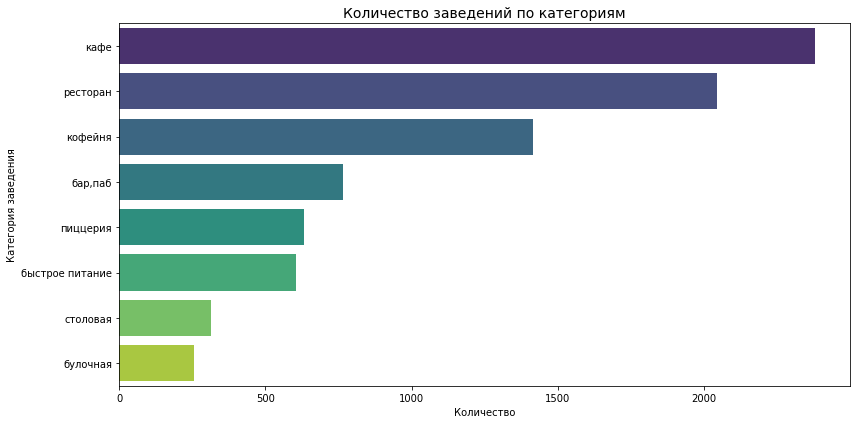

In [83]:
category_counts = rest_merged['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

viridis_palette = sns.color_palette("viridis", len(category_counts))

plt.figure(figsize=(12, 6))
sns.barplot(data=category_counts, x='count', y='category', palette=viridis_palette)
plt.title('Количество заведений по категориям', fontsize=14)
plt.xlabel('Количество')
plt.ylabel('Категория заведения')
plt.tight_layout()
plt.show()


На визуализации можно увидеть, что больше всего заведений типа "кафе" их 2378. 
Мееньше всего заведений типа "булочная" их 256 шт.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [84]:
district_ratios = rest_merged['district'].value_counts(normalize=True) * 100

relative_table = pd.DataFrame({
    'Доля (%)': district_ratios.round(2).map(lambda x: f"{x:.2f}")
})

display(relative_table)

,Доля (%)
Центральный административный округ,26.67
Северный административный округ,10.71
Южный административный округ,10.61
Северо-Восточный административный округ,10.60
Западный административный округ,10.12
Восточный административный округ,9.49
Юго-Восточный административный округ,8.49
Юго-Западный административный округ,8.43
Северо-Западный административный округ,4.87


In [85]:
district_counts = rest_merged['district'].value_counts()

absolute_table = pd.DataFrame({
    'Количество заведений': district_counts
})

display(absolute_table)

,Количество заведений
Центральный административный округ,2242
Северный административный округ,900
Южный административный округ,892
Северо-Восточный административный округ,891
Западный административный округ,851
Восточный административный округ,798
Юго-Восточный административный округ,714
Юго-Западный административный округ,709
Северо-Западный административный округ,409


<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исправили.</font>

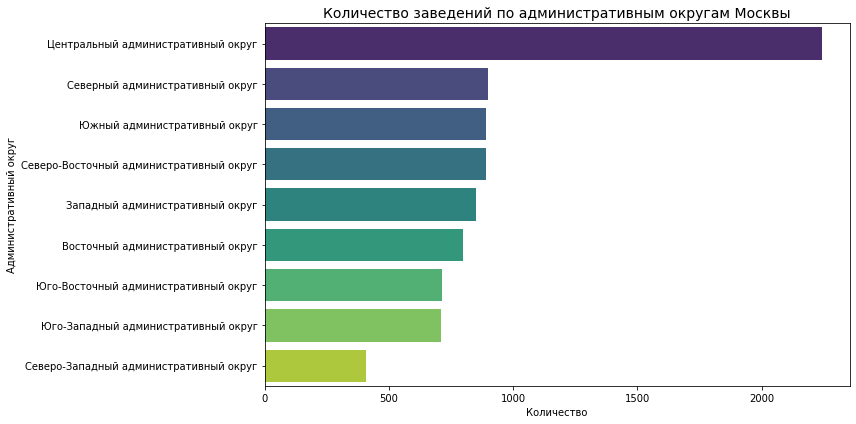

In [86]:
district_counts = rest_merged['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']

viridis_palette = sns.color_palette("viridis", len(district_counts))

plt.figure(figsize=(12, 6))
sns.barplot(data=district_counts, x='count', y='district', palette=viridis_palette)
plt.title('Количество заведений по административным округам Москвы', fontsize=14)
plt.xlabel('Количество')
plt.ylabel('Административный округ')
plt.tight_layout()
plt.show()

In [87]:
central_df = rest_merged[rest_merged['district'] == 'Центральный административный округ']

category_counts = central_df['category'].value_counts().reset_index()
category_counts.columns = ['Категория', 'Количество заведений']

absolute_table = category_counts.sort_values(by='Количество заведений', ascending=False).reset_index(drop=True)
display(absolute_table)

,Категория,Количество заведений
0,ресторан,670
1,кафе,464
2,кофейня,428
3,"бар,паб",364
4,пиццерия,113
5,быстрое питание,87
6,столовая,66
7,булочная,50


In [88]:
category_percent = (central_df['category'].value_counts(normalize=True) * 100).round(2).reset_index()
category_percent.columns = ['Категория', 'Доля (%)']

percent_table = category_percent.sort_values(by='Доля (%)', ascending=False).reset_index(drop=True)

display(percent_table)

,Категория,Доля (%)
0,ресторан,29.88
1,кафе,20.70
2,кофейня,19.09
3,"бар,паб",16.24
4,пиццерия,5.04
5,быстрое питание,3.88
6,столовая,2.94
7,булочная,2.23


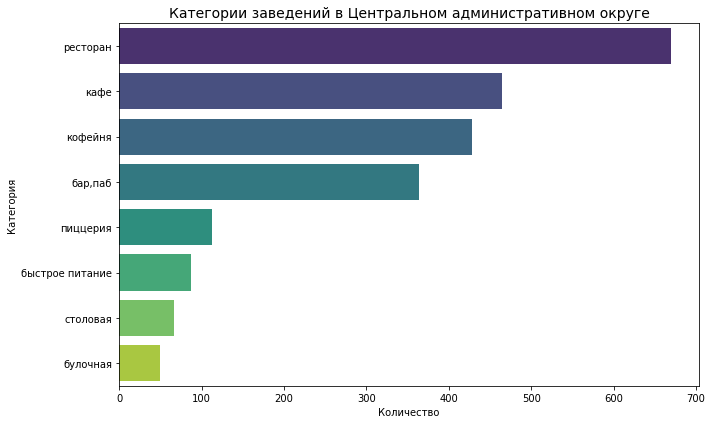

In [89]:
central_df = rest_merged[rest_merged['district'] == 'Центральный административный округ']

central_category_counts = central_df['category'].value_counts().reset_index()
central_category_counts.columns = ['category', 'count']

viridis_palette = sns.color_palette("viridis", len(central_category_counts))

plt.figure(figsize=(10, 6))
sns.barplot(data=central_category_counts, x='count', y='category', palette=viridis_palette)
plt.title('Категории заведений в Центральном административном округе', fontsize=14)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

На 1 визуализации видно что присутствует 9 административных округов Москвы. Больше всего заведений в Центральном округе. Меньше всего в Северо-Западном округе.
На 2 визуализации уже предоставленны данные по Центральному округу и категории заведений в нем. Можно заметить, что наибольшей попульрностью пользуются рестораны 670 шт., а уже потом кафе 464шт. Булочные же в свою очередь мало популярны и заведений 50 шт.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

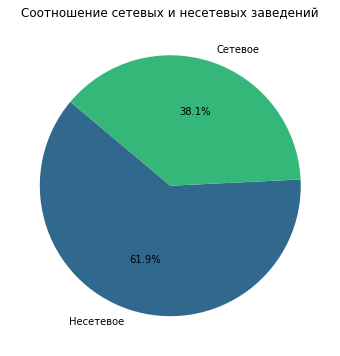

In [90]:
rest_merged['is_chain'] = rest_merged['chain'].map({1: 'Сетевое', 0: 'Несетевое'})

viridis_colors = sns.color_palette('viridis', 2)

chain_counts = rest_merged['is_chain'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    chain_counts,
    labels=chain_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=viridis_colors
)
plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

In [91]:
chain_counts = rest_merged['is_chain'].value_counts()

absolute_table = pd.DataFrame({
    'Количество заведений': chain_counts
})

display(absolute_table)

,Количество заведений
Несетевое,5201
Сетевое,3205


In [92]:
chain_ratios = rest_merged['is_chain'].value_counts(normalize=True) * 100

relative_table = pd.DataFrame({
    'Доля (%)': chain_ratios.round(2).map(lambda x: f"{x:.2f}")
})

display(relative_table)

,Доля (%)
Несетевое,61.87
Сетевое,38.13


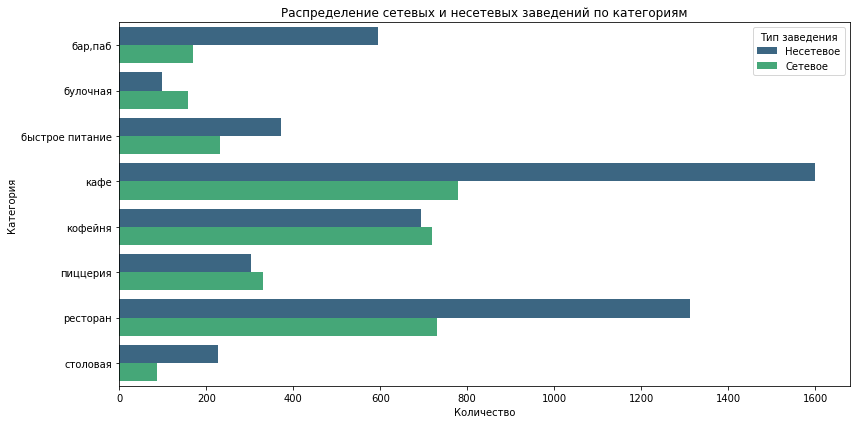

In [93]:
category_chain_counts = rest_merged.groupby(['category', 'is_chain']).size().reset_index(name='count')

viridis_colors = sns.color_palette('viridis', 2)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=category_chain_counts,
    x='count',
    y='category',
    hue='is_chain',
    palette=viridis_colors
)
plt.title('Распределение сетевых и несетевых заведений по категориям')
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.legend(title='Тип заведения')
plt.tight_layout()
plt.show()

In [94]:
category_chain_counts = rest_merged.groupby(['category', 'is_chain']).size().reset_index(name='Количество заведений')

category_chain_counts['is_chain'] = pd.Categorical(
    category_chain_counts['is_chain'],
    categories=['Сетевое', 'Несетевое'],
    ordered=True
)

category_chain_counts = category_chain_counts.sort_values(by=['is_chain', 'category'])

display(category_chain_counts)

,category,is_chain,Количество заведений
1,"бар,паб",Сетевое,169
3,булочная,Сетевое,157
5,быстрое питание,Сетевое,232
7,кафе,Сетевое,779
9,кофейня,Сетевое,720
11,пиццерия,Сетевое,330
13,ресторан,Сетевое,730
15,столовая,Сетевое,88
0,"бар,паб",Несетевое,596
2,булочная,Несетевое,99


In [95]:
category_chain_counts['Доля (%)'] = category_chain_counts.groupby('category')['Количество заведений'].apply(
    lambda x: (x / x.sum() * 100).round(2)
)

relative_table = category_chain_counts[['is_chain', 'category', 'Доля (%)']]
relative_table = relative_table.sort_values(by=['is_chain', 'category'])

display(relative_table)

,is_chain,category,Доля (%)
1,Сетевое,"бар,паб",22.09
3,Сетевое,булочная,61.33
5,Сетевое,быстрое питание,38.47
7,Сетевое,кафе,32.76
9,Сетевое,кофейня,50.96
11,Сетевое,пиццерия,52.13
13,Сетевое,ресторан,35.73
15,Сетевое,столовая,27.94
0,Несетевое,"бар,паб",77.91
2,Несетевое,булочная,38.67


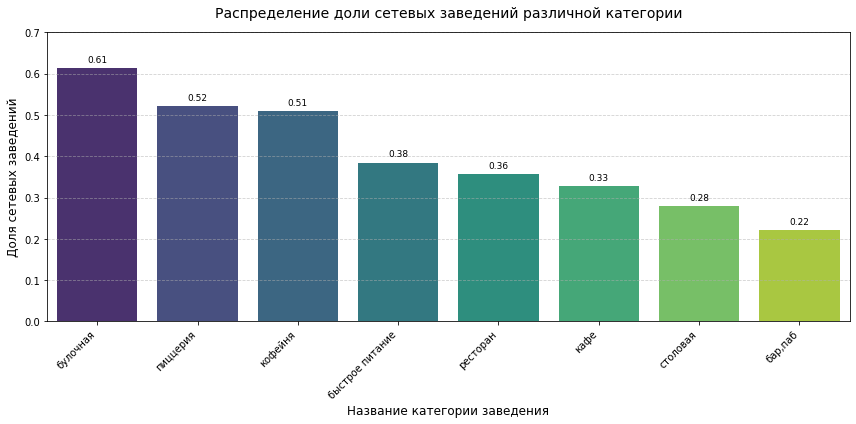

In [96]:
chain_share = category_chain_counts[category_chain_counts['is_chain'] == 'Сетевое'].copy()

chain_share['Доля (доля)'] = chain_share['Доля (%)'] / 100

chain_share_sorted = chain_share.sort_values(by='Доля (доля)', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=chain_share_sorted,
    x='category',
    y='Доля (доля)',
    palette='viridis'
)

for i, row in enumerate(chain_share_sorted['Доля (доля)']):
    ax.text(
        i,                      
        row + 0.01,             
        f"{row:.2f}",           
        ha='center', va='bottom',
        fontsize=9
    )

    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title('Распределение доли сетевых заведений различной категории', fontsize=14, pad=15)
plt.xlabel('Название категории заведения', fontsize=12)
plt.ylabel('Доля сетевых заведений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, 0.8, 0.1))  
plt.ylim(0, 0.7)                    
plt.tight_layout()
plt.show()

Построены 2 визуализации. На 1 показано соотношение сетевых и несетевых заведений и разница между ними весьма существенна(Сетевых-3205шт. Несетевых-5201шт). На 2 визуализации уже показано распределение заведений по категориям. Отвечая на вопрос можно сказать, что чаще всего заведения типа "булочная"(0.61) являются сетевыми,далее идут "пиццерия"(0.52) и "кофейня"(0.51)

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [97]:
seats_stats = rest_merged['seats'].describe()
print(seats_stats)

missing_seats = rest_merged['seats'].isna().sum()
print(f'Пропущено значений seats: {missing_seats}')

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64
Пропущено значений seats: 3611


In [98]:
rest_merged['seats'] = pd.to_numeric(rest_merged['seats'], errors='coerce')

rest_clean = rest_merged[rest_merged['seats'].notna() & (rest_merged['seats'] > 0)].copy()

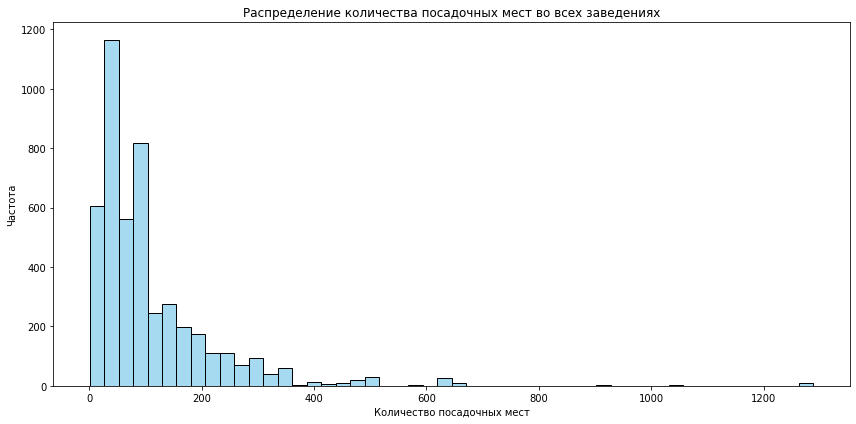

In [99]:
plt.figure(figsize=(12, 6))
sns.histplot(rest_clean['seats'], bins=50, color='skyblue')
plt.title('Распределение количества посадочных мест во всех заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

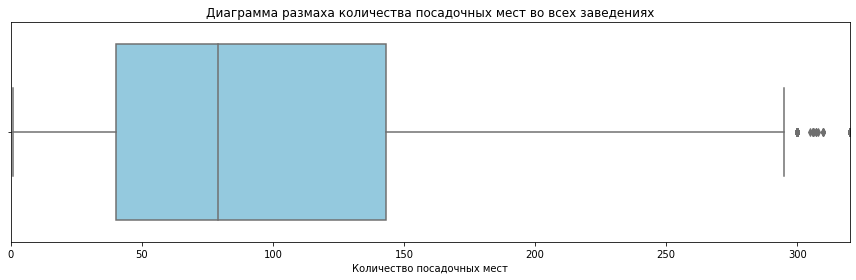

In [100]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=rest_clean['seats'], color='skyblue')
plt.title('Диаграмма размаха количества посадочных мест во всех заведениях')
plt.xlabel('Количество посадочных мест')
plt.xlim(0, rest_clean['seats'].quantile(0.95))
plt.tight_layout()
plt.show()


In [101]:
q99 = rest_clean['seats'].quantile(0.99)
print(f'99-й перцентиль количества посадочных мест: {q99:.0f}')

outliers = rest_clean[rest_clean['seats'] > q99]
print(f'Количество заведений с количеством посадочных мест выше 99-го перцентиля: {len(outliers)}')

99-й перцентиль количества посадочных мест: 625
Количество заведений с количеством посадочных мест выше 99-го перцентиля: 30


In [102]:
typical_seats = rest_merged.groupby('category')['seats'].median().sort_values(ascending=False)
print(typical_seats)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64


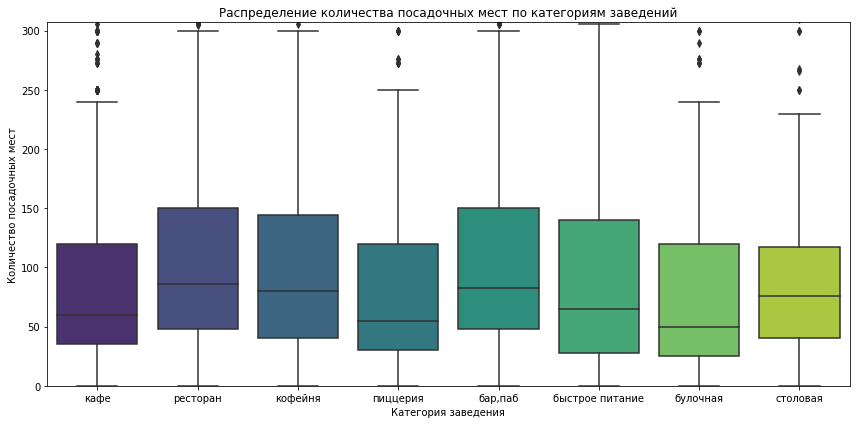

In [103]:
plt.figure(figsize=(12,6))
sns.boxplot(data=rest_merged, x='category', y='seats', palette='viridis')
plt.title('Распределение количества посадочных мест по категориям заведений')
plt.xlabel('Категория заведения')
plt.ylabel('Количество посадочных мест')
plt.ylim(0, rest_merged['seats'].quantile(0.95))
plt.tight_layout()
plt.show()

В данных встречаются аномальные значения их 30 заведений, они и являются выбросами. Большие заведения с залами для мероприятий, конференций или фуршетов. Крупные сети или рестораны с несколькими залами. Возможно, в данных есть и ошибки (например, если 1288 — это дублирование, либо техническая ошибка в заполнении), но чаще всего — это крупные заведения.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [104]:
rest_merged['rating'].describe()

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [105]:
category_rating_desc = rest_merged.groupby('category')['rating'].describe().sort_values(by='mean', ascending=False)
display(category_rating_desc) 

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",765.0,4.387712,0.380143,1.1,4.3,4.4,4.6,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2043.0,4.290358,0.413046,1.0,4.2,4.3,4.5,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0
кафе,2378.0,4.123886,0.566081,1.0,4.0,4.2,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0


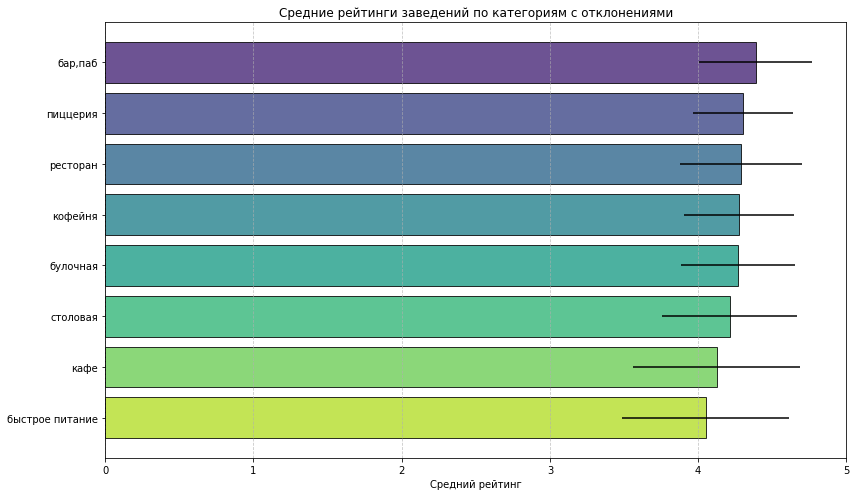

In [106]:

rating_stats = rest_merged.groupby('category')['rating'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(
    rating_stats.index,
    rating_stats['mean'],
    xerr=rating_stats['std'],
    color=sns.color_palette('viridis', len(rating_stats)),
    edgecolor='black',
    alpha=0.8
)
plt.xlabel('Средний рейтинг')
plt.title('Средние рейтинги заведений по категориям с отклонениями')
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Отвечая на поставленный вопрос. Нет, отклонение различия усреднённого рейтинга для разных типов общепита не большое 

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [107]:
correlation_columns = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7',]
df_corr= rest_merged[correlation_columns].copy()
df_corr.head()

,rating,category,district,chain,seats,price,is_24_7
0,5.0,кафе,Северный административный округ,0,<NA>,NaN,False
1,4.5,ресторан,Северный административный округ,0,4,выше среднего,False
2,4.6,кафе,Северный административный округ,0,45,средние,False
3,5.0,кофейня,Северный административный округ,0,<NA>,NaN,False
4,5.0,пиццерия,Северный административный округ,1,148,средние,False


In [108]:
show_missing_stats(df_corr)

NameError: name 'show_missing_stats' is not defined

In [109]:
df_corr = df_corr.replace(['unknown',  -1], np.nan)

In [110]:
df_corr.head()

,rating,category,district,chain,seats,price,is_24_7
0,5.0,кафе,Северный административный округ,0,<NA>,NaN,False
1,4.5,ресторан,Северный административный округ,0,4,выше среднего,False
2,4.6,кафе,Северный административный округ,0,45,средние,False
3,5.0,кофейня,Северный административный округ,0,<NA>,NaN,False
4,5.0,пиццерия,Северный административный округ,1,148,средние,False


Матрица корреляций.

In [111]:
correlation_matrix=df_corr.phik_matrix(interval_cols=['rating','seats'])
correlation_matrix

,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.198949,0.189389,0.119071,0.000000,0.262056,0.160804
category,0.198949,1.000000,0.174326,0.265627,0.048186,0.566933,0.244789
district,0.189389,0.174326,1.000000,0.064233,0.352496,0.202787,0.076392
chain,0.119071,0.265627,0.064233,1.000000,0.056563,0.218211,0.043414
seats,0.000000,0.048186,0.352496,0.056563,1.000000,0.065308,0.043278
price,0.262056,0.566933,0.202787,0.218211,0.065308,1.000000,0.084183
is_24_7,0.160804,0.244789,0.076392,0.043414,0.043278,0.084183,1.000000


In [112]:
correlation_matrix = df_corr[['district', 'category', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198949
district,0.189389
is_24_7,0.160804
chain,0.119071
seats,0.000000


In [113]:
# Сортировка по корреляции с 'rating'
corr_with_rating = correlation_matrix['rating'].sort_values(ascending=False)
print("Корреляция признаков с рейтингом:\n", corr_with_rating)

Корреляция признаков с рейтингом:
 rating      1.000000
price       0.262056
category    0.198949
district    0.189389
is_24_7     0.160804
chain       0.119071
seats       0.000000
Name: rating, dtype: float64


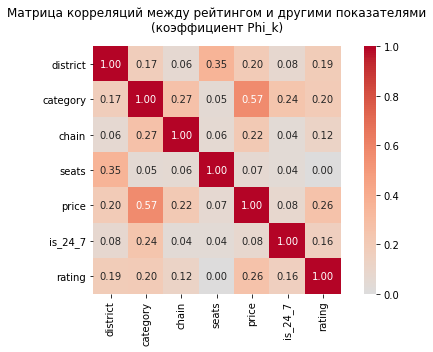

In [114]:
plt.figure(figsize=(7, 5))

sns.heatmap(correlation_matrix,
            annot=True,       # Отображаем численные значения в ячейках карты
            fmt='.2f',        # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm',  # Цветовая гамма от красного (макс. значение) к синему
            center=0,         # Центр цветовой шкалы
            square=True       # Квадратные ячейки
           )

plt.title('Матрица корреляций между рейтингом и другими показателями\n(коэффициент Phi_k)',
          fontsize=12, pad=15)
plt.tight_layout()

plt.show()

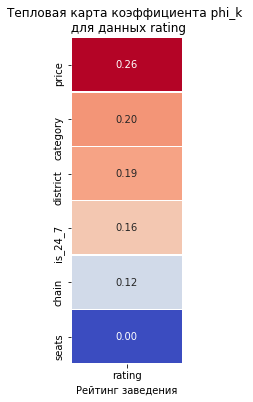

In [115]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data,
            annot=True, 		# Отображаем численные значения в ячейках карты
            fmt='.2f', 			# Форматируем значения корреляции: два знака после точки
            cmap='coolwarm',	# Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, 	# Форматируем линию между ячейками карты
            cbar=False 			# Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')

# Выводим график
plt.show() 

In [116]:
max_corr_col = correlation_matrix['rating'].drop('rating').idxmax()
print(f"Признак с самой сильной корреляцией с рейтингом: {max_corr_col}")

# Средние значения рейтинга по категориям выбранного признака
mean_rating = rest_merged.groupby(max_corr_col)['rating'].mean().sort_values(ascending=False)

Признак с самой сильной корреляцией с рейтингом: price


Признак (price) демонстрирует наибольшую связь с рейтингом, с коэффициентом корреляции 0.26. Рассмотрим эту зависимость более детально и визуализируем её. Построим столбчатую диаграмму средних рейтингов по ценовым категориям, чтобы наглядно показать, как рейтинг изменяется при переходе между категориями.

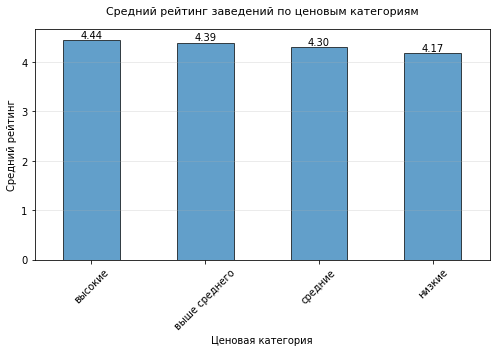

In [117]:
price_rating = rest_merged.groupby('price')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
ax = price_rating.plot(kind='bar',
                       edgecolor='black',
                       alpha=0.7,
                       figsize=(7,5))

plt.title('Средний рейтинг заведений по ценовым категориям', fontsize=11, pad=15)
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(price_rating.values):
    ax.text(i, value + 0.01, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [118]:
 #Комментарий ревьюера 2
len(rest_merged), len(df_corr) 

(8406, 8406)

Корреляции между рейтингом заведений и другими признаками, самая сильная связь наблюдается с признаком price(округ Москвы), с коэффициентом = 0.26. С ростом ценового цровня средний рейтинг увеличивается.


Ценовая политика влияет на ожидания клиентов и последующую оченку. Повышенный прайс должен быть оправдан соответствующим качеством обслуживания, тогда она может способствовать получению высоких рейтингов. Посетители ожидают лучшего обслуживания за большие деньги и при его получении ставят высокую оценку. Дорогие заведения могут позволить себе инвестировать в качество сервиса, повышения кваллиффикации персонала и улучшение интерьера.

При открытии заведения с повышенными ценами: необходимо соответствовать ожиданиям посетителей премиум сегмента. При качественной реализации можно расчитывать на повышенныую оценку. Требуется значительная доля инвестиции в заведение(от персонала до атмосферы заведения)

Если открывать заведение не премиум сегмента  рост рейтинга достигается не за счет премиального сервиса, а за счет оптимального сочетания цены и качества, удобства, чистоты и внимательности к клиентам. Даже при ограниченном бюджете можно получить высокие оценки, если посетитель чувствует, что его ожидания полностью оправданы.

Вывокий прайс сам по себе не гарантирует высокий рейтинг т.к корреляции не означает каузальность

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [119]:
chain_data = rest_merged[rest_merged['chain'] == 1].copy()

pivot = chain_data.groupby('name').agg(
    category=('category', lambda x: x.mode()[0] if not x.mode().empty else None),
    count=('name', 'size'),
    avg_rating=('rating', 'mean')
).reset_index()

pivot_sorted = pivot.sort_values(by='count', ascending=False).head(15)

display(pivot_sorted)

,name,category,count,avg_rating
729,шоколадница,кофейня,120,4.177500
335,домино'с пицца,пиццерия,76,4.169737
331,додо пицца,пиццерия,74,4.286487
146,one price coffee,кофейня,71,4.064789
742,яндекс лавка,ресторан,69,3.872464
58,cofix,кофейня,65,4.075385
168,prime,ресторан,50,4.116000
664,хинкальная,кафе,44,4.322727
409,кофепорт,кофейня,42,4.147619
418,кулинарная лавка братьев караваевых,кафе,39,4.394872


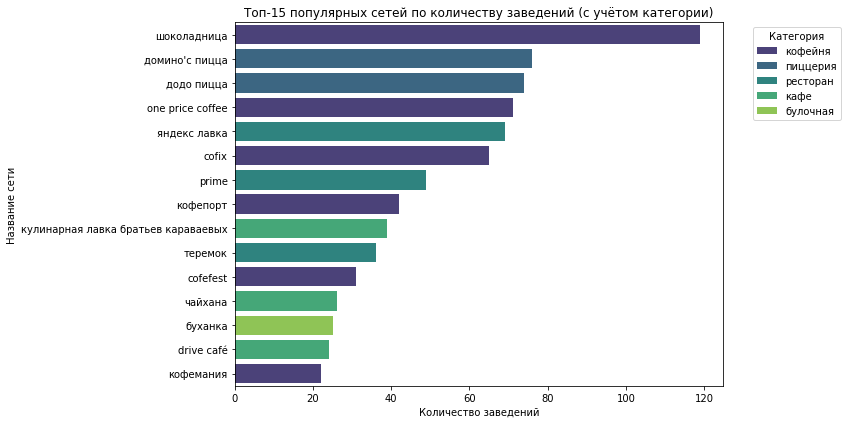

In [120]:
plt.figure(figsize=(12, 6))

top_chains = (
    rest_merged[rest_merged['chain'] == 1]
    .groupby(['name', 'category'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
    .head(15)
)

sns.barplot(
    data=top_chains,
    y='name',
    x='count',
    hue='category',
    dodge=False,
    palette='viridis'
)

plt.title('Топ-15 популярных сетей по количеству заведений (с учётом категории)')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [121]:
# Комментарий ревьюера
tmp = rest_merged.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


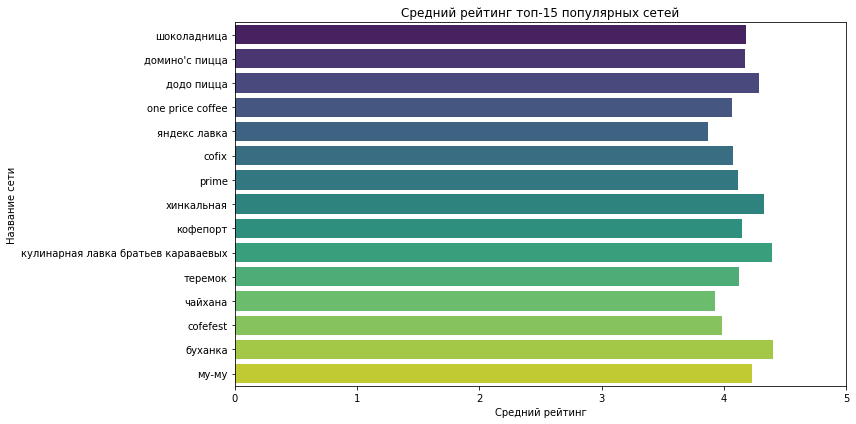

In [122]:
top15_chains = (
    rest_merged[rest_merged['chain'] == 1]
    .groupby('name')
    .agg(count=('id', 'size'), avg_rating=('rating', 'mean'))
    .sort_values(by='count', ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top15_chains, y='name', x='avg_rating', palette='viridis')
plt.title('Средний рейтинг топ-15 популярных сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [123]:
chain_stats = (
    rest_merged[rest_merged['chain'] == 1]
    .groupby('name')
    .agg(
        count=('id', 'size'),
        avg_rating=('rating', 'mean'),
        top_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')
    )
    .reset_index())

print(chain_stats[['name', 'count', 'avg_rating', 'top_category']])

                  name  count  avg_rating top_category
0      1-я креветочная      1    3.700000         кафе
1    10 идеальных пицц      3    4.300000     ресторан
2             18 грамм      3    4.466667      кофейня
3             4 сезона      1    4.700000         кафе
4          7 сэндвичей      4    3.975000      кофейня
..                 ...    ...         ...          ...
742       яндекс лавка     69    3.872464     ресторан
743       яндекс.лавка      3    3.466667     ресторан
744     японская кухня      4    4.425000         кафе
745             ё-ланч      2    4.000000     столовая
746                ёрш      2    4.400000      бар,паб

[747 rows x 4 columns]


Топ-15 сетей представлены в основном категориями кофейня, пиццерия, ресторан, кафе, а также есть булочная.
Наиболее популярная сеть — "шоколадница" (кофейня) с 120 заведениями.
Средний рейтинг у большинства сетей довольно высокий (около 4 и выше).

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [124]:
bill_data = rest_merged[['district', 'middle_avg_bill']].dropna()

display(bill_data['middle_avg_bill'].describe())

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

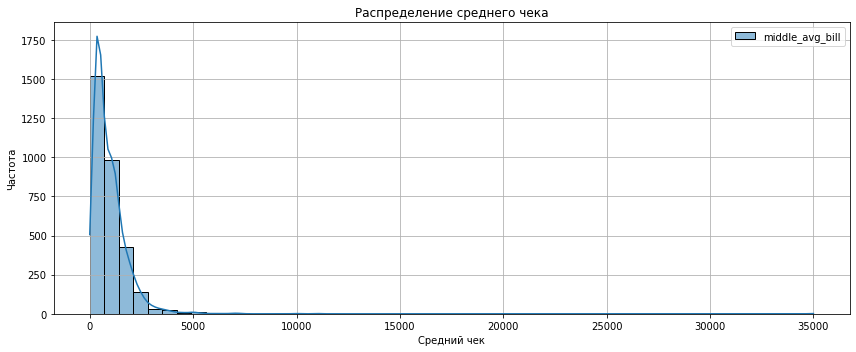

In [125]:
plt.figure(figsize=(12, 5))
sns.histplot(bill_data, bins=50, kde=True, color='skyblue')
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
plt.grid(True)
plt.tight_layout()
plt.show()

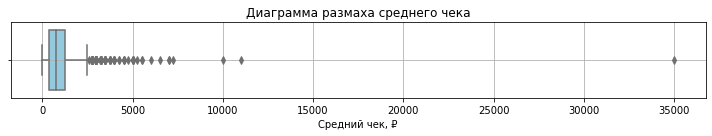

In [126]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=bill_data['middle_avg_bill'], color='skyblue')
plt.title('Диаграмма размаха среднего чека')
plt.xlabel('Средний чек, ₽')
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
df_prices = rest_merged[['district', 'middle_avg_bill']].dropna()

district_stats = df_prices.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).reset_index()

display(district_stats.sort_values(by='median', ascending=False))

,district,median,mean
1,Западный административный округ,1000.0,1053.225464
5,Центральный административный округ,1000.0,1191.057495
4,Северо-Западный административный округ,700.0,822.222900
2,Северный административный округ,650.0,927.959656
7,Юго-Западный административный округ,600.0,792.561707
0,Восточный административный округ,575.0,820.626953
3,Северо-Восточный административный округ,500.0,716.611267
8,Южный административный округ,500.0,834.398071
6,Юго-Восточный административный округ,450.0,654.097961


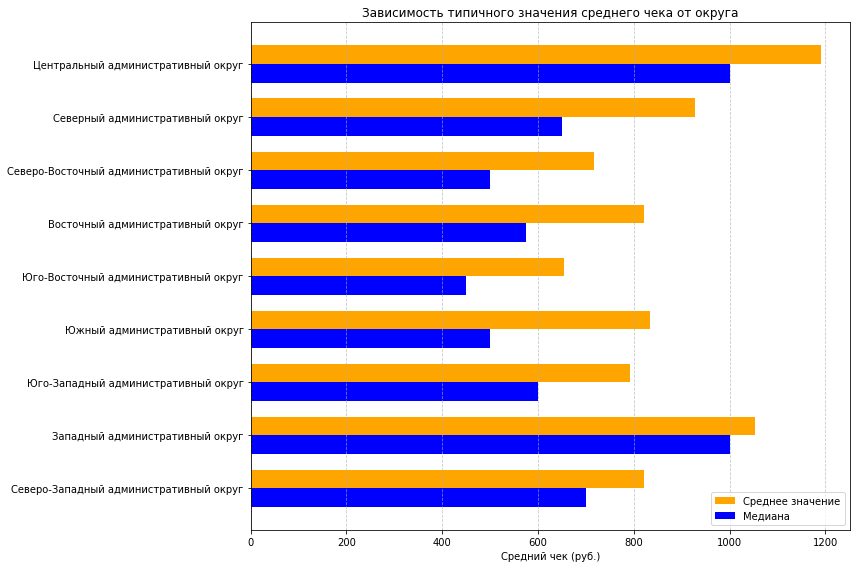

In [128]:

district_order = [
    'Центральный административный округ',
    'Северный административный округ',
    'Северо-Восточный административный округ',
    'Восточный административный округ',
    'Юго-Восточный административный округ',
    'Южный административный округ',
    'Юго-Западный административный округ',
    'Западный административный округ',
    'Северо-Западный административный округ'
]

filtered_data = rest_merged.dropna(subset=['middle_avg_bill'])

median_bill = filtered_data.groupby('district')['middle_avg_bill'].median().reindex(district_order)
mean_bill = filtered_data.groupby('district')['middle_avg_bill'].mean().reindex(district_order)

y = np.arange(len(district_order))
height = 0.35

plt.figure(figsize=(12, 8))
plt.barh(y - height/2, mean_bill, height, color='orange', label='Среднее значение')
plt.barh(y + height/2, median_bill, height, color='blue', label='Медиана')

plt.yticks(y, district_order)
plt.gca().invert_yaxis()

plt.xlabel('Средний чек (руб.)')
plt.title('Зависимость типичного значения среднего чека от округа')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

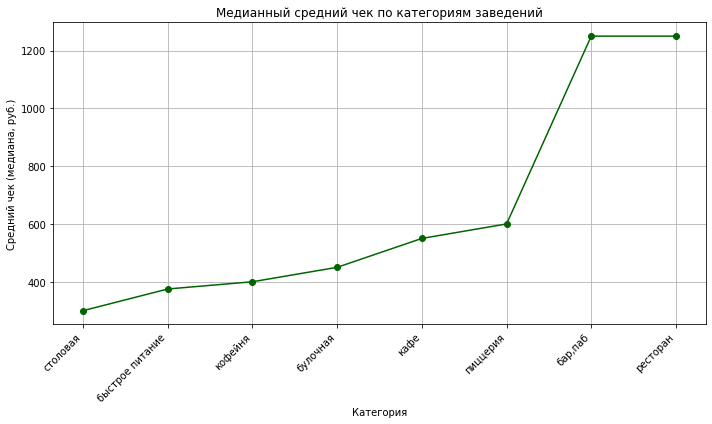

In [129]:
avg_bill_by_category = rest_merged.groupby('category')['middle_avg_bill'].median().sort_values()

plt.figure(figsize=(10, 6))
plt.plot(avg_bill_by_category.index, avg_bill_by_category.values, marker='o', color='darkgreen')
plt.xticks(rotation=45, ha='right')
plt.title('Медианный средний чек по категориям заведений')
plt.xlabel('Категория')
plt.ylabel('Средний чек (медиана, руб.)')
plt.grid(True)
plt.tight_layout()
plt.show()

---


Центральный и Западный округа — самые дорогие по среднему чеку:
Средние и медианные значения в этих округах близки и достигают 1000+ рублей.
Центральный округ имеет самый высокий средний чек (~1191 руб), что логично — это центр города с более дорогими заведениями.
В Центральном округе среднее выше медианы на ~190 рублей, что говорит о наличии очень дорогих заведений, которые тянут среднее вверх.
Самые дешевые округа — Юго-Восточный и Северо-Восточный:
Медиана около 450-500 рублей, среднее тоже самое или чуть выше.
Это окраинные районы, где, как правило, рестораны и кафе имеют более демократичные цены.
Чем ближе к центру, тем выше средний и медианный чек.
Удалённость от центра коррелирует с понижением цен.
При этом разброс цен (разница между средним и медианным) свидетельствует о более высокой ценовой дифференциации в центральных округах.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

Мною было составлено 8 граффиков и по ним можно сделать следующие выводы:
- больше всего заведений категории кафе их более 2000 шт. меньше всего категории булочная их меньше 500шт.
- больше всего заведений находятся в Центральном округе москвы. Меньше всего в Северо-западном округе.
- В центральном округе пристствует больше всего ресторанов почти 700 заведений и меньше всего булочных менее 100 заведений.
- из всех заведений больше не сетевых (61.9%).
- не сетевых заведений больше типа кафе и ресторанов.
- средние рейтинги всех типов заведений практически одинаковы( более4.)
- самыми популярными сетями по количеству заведений являются Шоколадница, Доминос Пицца и Додо Пицца.
- медианный средний чек выше всего в Центральном и Западном округах.
- медианный средний чек по категориям заведений у баров и ресторанов.

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

В рамках данного проекта был проведён исследовательский анализ данных за лето 2022года. Первоначально были загружены и изучены два набора данных, которые затем были объединены в один общий датафрейм для дальнейшего анализа. Проведена предобработка: обработаны пропуски (наибольшее количество — в столбце middle_coffee_cup, где отсутствуют данные в ~93.6% строк), удалены или проверены дубликаты (0 полных, 4 неявных), а также создан новый столбец, отражающий время работы заведений. Для ответа на исследовательские вопросы и визуализации ключевых тенденций построено 8 графиков.
Самым популярным типом заведения является Кафе(более 2000шт), больше всего заведений в Центральном округе(более 2000) и бльшинство из них не являются ситевыми(61.9%)

Рекомендации:

Следить за трендами: здоровье‑питание, растительное меню, экология, формат “street‑food”, открытые террасы.

Эксперементировать: запуск pop‑up‑кафе, маркетинговые акции, коллаборации с блогерами.

Собирать обратную связь с поситителей и подстраиваься под пожелания.

Изучить конкурентов и целевую аудиторию в зависимости от локации заведения.

Медианный средний чек выше всего в Центральном и Западном округах следовательно для открытия рекомендуются эти округа,преимущественно Центральный.